# 📊 Proyecto Integrador — Bootcamp de Data Science
## E-commerce Transactions + Clickstream Dataset

**Tablas analizadas:** `customers.csv`, `sessions.csv`

## 0. Configuración del entorno

Importación de librerías y configuración de estilo para todas las visualizaciones del notebook.

In [1]:
# Librerías de manipulación de datos
import pandas as pd
import numpy as np

# Librerías de visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo profesional para todos los gráficos
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titleweight'] = 'bold'

# Configuración de pandas para ver todas las columnas sin truncar
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print("Entorno configurado correctamente.")


Entorno configurado correctamente.


In [2]:
# Carga de los dos archivos CSV entregados para el proyecto
customers = pd.read_csv('customers.csv')
sessions  = pd.read_csv('sessions.csv')

print(f"customers.csv -> {customers.shape[0]:,} filas x {customers.shape[1]} columnas")
print(f"sessions.csv  -> {sessions.shape[0]:,} filas x {sessions.shape[1]} columnas")


FileNotFoundError: [Errno 2] No such file or directory: 'customers.csv'

---
# FASE 1 — Análisis Exploratorio de las Tablas

## 1.1 `customers.csv`

### Objetivo de la tabla
`customers.csv` es la **tabla maestra de clientes**. Contiene un registro por cada cliente único que se ha registrado en la plataforma de e-commerce, con sus atributos demográficos y de contacto. Es la tabla de referencia (dimensión) que permite identificar **quién es** cada cliente.


In [ ]:
# Número de registros y columnas
n_rows, n_cols = customers.shape
print(f"Número de registros (clientes): {n_rows:,}")
print(f"Número de columnas: {n_cols}")
print(f"\nColumnas: {list(customers.columns)}")


Número de registros (clientes): 20,000
Número de columnas: 7

Columnas: ['customer_id', 'name', 'email', 'country', 'age', 'signup_date', 'marketing_opt_in']


In [ ]:
# Tipo de dato de cada columna (según pandas)
customers.dtypes.to_frame(name='tipo_de_dato_pandas')


,tipo_de_dato_pandas
customer_id,int64
name,object
email,object
country,object
age,int64
signup_date,object
marketing_opt_in,bool


In [ ]:
# Vista previa de los primeros registros
customers.head(5)


,customer_id,name,email,country,age,signup_date,marketing_opt_in
0,1,Jennifer Salinas,nicholas59@example.org,JP,71,2020-09-04,True
1,2,Phillip Ramos,christinarubio@example.com,IN,26,2020-04-05,False
2,3,Dawn Fowler,jessica03@example.org,BR,21,2023-08-31,True
3,4,Mario Butler,paula27@example.org,FR,63,2022-06-30,True
4,5,Amber Brown,kevin85@example.net,BR,19,2022-07-22,True


### Diccionario de datos — `customers.csv`

| # | Columna | Tipo (pandas) | Tipo real de negocio | Descripción |
|---|---|---|---|---|
| 1 | `customer_id` | int64 | Identificador único | Llave primaria del cliente. No presenta duplicados (verificado abajo). |
| 2 | `name` | object (str) | Texto | Nombre completo del cliente (dato sintético/ficticio). |
| 3 | `email` | object (str) | Texto / contacto | Correo electrónico del cliente. Único por cliente (verificado abajo). |
| 4 | `country` | object (str) | Categórica (código ISO-2) | País de registro del cliente, codificado en 2 letras (ej. `US`, `IN`, `GB`). |
| 5 | `age` | int64 | Numérica discreta | Edad del cliente en años. |
| 6 | `signup_date` | object (str, se convierte a datetime) | Fecha | Fecha en la que el cliente se registró en la plataforma. |
| 7 | `marketing_opt_in` | bool | Booleana | Indica si el cliente aceptó recibir comunicaciones de marketing (`True`/`False`). |

**Nota:** estas son **todas** las columnas presentes en el archivo real. No existen columnas de género (`gender`), segmento, ciudad, dirección, ni ningún identificador de compra en esta tabla — si el modelo de negocio las requiere, deberán solicitarse en una fase posterior o confirmarse que no están disponibles en el dataset.


## 1.2 `sessions.csv`

### Objetivo de la tabla
`sessions.csv` es una **tabla de eventos de comportamiento (clickstream)**. Contiene un registro por cada **sesión de navegación** que un cliente realizó en el sitio web, con el momento, el dispositivo y el canal de origen. Es la tabla que permite entender **cómo y cuándo interactúan** los clientes con la plataforma. No es una tabla de transacciones: no contiene productos, montos ni indicadores de compra.


In [ ]:
# Número de registros y columnas
n_rows_s, n_cols_s = sessions.shape
print(f"Número de registros (sesiones): {n_rows_s:,}")
print(f"Número de columnas: {n_cols_s}")
print(f"\nColumnas: {list(sessions.columns)}")


Número de registros (sesiones): 120,000
Número de columnas: 6

Columnas: ['session_id', 'customer_id', 'start_time', 'device', 'source', 'country']


In [ ]:
# Tipo de dato de cada columna (según pandas)
sessions.dtypes.to_frame(name='tipo_de_dato_pandas')


,tipo_de_dato_pandas
session_id,int64
customer_id,int64
start_time,object
device,object
source,object
country,object


In [ ]:
# Vista previa de los primeros registros
sessions.head(5)


,session_id,customer_id,start_time,device,source,country
0,1,12360,2021-12-27T00:01:36,mobile,email,DE
1,2,13917,2025-01-31T21:29:42,desktop,organic,PL
2,3,1022,2024-02-19T00:52:50,tablet,organic,FR
3,4,2882,2024-08-04T19:54:31,mobile,direct,GB
4,5,1286,2022-06-28T13:58:08,desktop,email,ES


### Diccionario de datos — `sessions.csv`

| # | Columna | Tipo (pandas) | Tipo real de negocio | Descripción |
|---|---|---|---|---|
| 1 | `session_id` | int64 | Identificador único | Llave primaria de la sesión. No presenta duplicados (verificado abajo). |
| 2 | `customer_id` | int64 | Llave foránea | Referencia al cliente (`customers.customer_id`) que originó la sesión. |
| 3 | `start_time` | object (str, se convierte a datetime) | Fecha y hora | Momento exacto (timestamp) de inicio de la sesión. |
| 4 | `device` | object (str) | Categórica | Tipo de dispositivo usado: `mobile`, `desktop` o `tablet`. |
| 5 | `source` | object (str) | Categórica | Canal de adquisición/origen de la sesión: `organic`, `direct`, `paid`, `social`, `email`, `referral`. |
| 6 | `country` | object (str) | Categórica (código ISO-2) | País desde el cual se originó la sesión. |

**Nota:** estas son **todas** las columnas presentes en el archivo real. No existen columnas de duración de sesión, páginas vistas, producto visitado, carrito de compra ni conversión. Por lo tanto, **no es posible calcular con estos datos**: tasa de conversión, ticket promedio, productos más vistos/comprados, ni ningún indicador monetario. Esto se reitera porque condiciona directamente el alcance de la Fase 2.


## 1.3 Calidad de datos

Se evalúan tres dimensiones de calidad para ambas tablas: **valores nulos**, **duplicados** e **inconsistencias** (formatos, rangos, tipos).


In [ ]:
# --- VALORES NULOS ---
print("Valores nulos por columna - customers.csv")
print(customers.isnull().sum())
print("\nValores nulos por columna - sessions.csv")
print(sessions.isnull().sum())

print("\nPorcentaje de nulos - customers.csv (%)")
print((customers.isnull().mean()*100).round(2))
print("\nPorcentaje de nulos - sessions.csv (%)")
print((sessions.isnull().mean()*100).round(2))


Valores nulos por columna - customers.csv
customer_id         0
name                0
email               0
country             0
age                 0
signup_date         0
marketing_opt_in    0
dtype: int64

Valores nulos por columna - sessions.csv
session_id     0
customer_id    0
start_time     0
device         0
source         0
country        0
dtype: int64

Porcentaje de nulos - customers.csv (%)
customer_id         0.0
name                0.0
email               0.0
country             0.0
age                 0.0
signup_date         0.0
marketing_opt_in    0.0
dtype: float64

Porcentaje de nulos - sessions.csv (%)
session_id     0.0
customer_id    0.0
start_time     0.0
device         0.0
source         0.0
country        0.0
dtype: float64


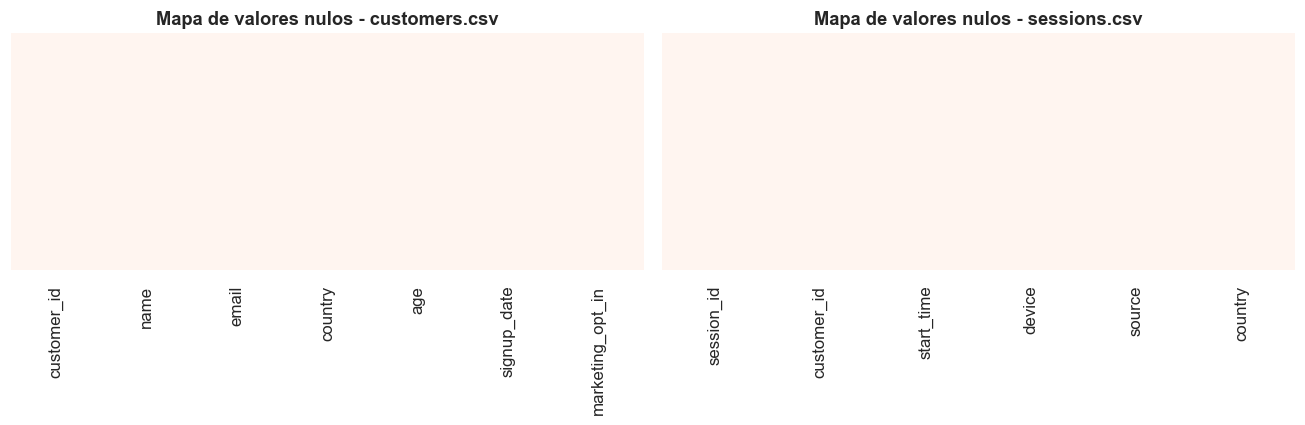

In [ ]:
# Mapa de calor de valores nulos (heatmap) para ambas tablas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(customers.isnull(), cbar=False, cmap='Reds', yticklabels=False, ax=axes[0])
axes[0].set_title('Mapa de valores nulos - customers.csv')
sns.heatmap(sessions.isnull(), cbar=False, cmap='Reds', yticklabels=False, ax=axes[1])
axes[1].set_title('Mapa de valores nulos - sessions.csv')
plt.tight_layout()
plt.show()


**Interpretación técnica:** las franjas completamente vacías (sin color rojo) confirman que ninguna columna de ninguna de las dos tablas presenta valores nulos.

**Insight de negocio:** el dataset tiene una calidad excepcionalmente alta en cuanto a completitud (0% de nulos en las 13 columnas combinadas). Esto reduce significativamente el esfuerzo de limpieza y permite confiar en los indicadores agregados (edades, países, fechas) sin necesidad de imputación.


In [ ]:
# --- DUPLICADOS ---
print("customers.csv")
print(" - Filas totalmente duplicadas:", customers.duplicated().sum())
print(" - customer_id duplicados:", customers['customer_id'].duplicated().sum())
print(" - email duplicados (case-insensitive):", customers['email'].str.lower().duplicated().sum())
print(" - name duplicados (nombre y apellido repetido):", customers['name'].duplicated().sum())

print("\nsessions.csv")
print(" - Filas totalmente duplicadas:", sessions.duplicated().sum())
print(" - session_id duplicados:", sessions['session_id'].duplicated().sum())


customers.csv
 - Filas totalmente duplicadas: 0
 - customer_id duplicados: 0
 - email duplicados (case-insensitive): 0
 - name duplicados (nombre y apellido repetido): 2085

sessions.csv
 - Filas totalmente duplicadas: 0
 - session_id duplicados: 0


**Interpretación técnica:** no existen filas duplicadas ni duplicados en las llaves primarias (`customer_id`, `session_id`, `email`). Sí se observan **2,085 nombres repetidos** en `name`, lo cual es esperable estadísticamente (nombres comunes como "John Smith" pueden repetirse entre miles de personas reales) y **no representa un problema de calidad**, ya que la unicidad real del cliente está garantizada por `customer_id` y `email`.

**Insight de negocio:** la ausencia de duplicados en las llaves primarias garantiza que los conteos de clientes y sesiones que se presentan en este informe son fiables y no están inflados por registros repetidos.


In [ ]:
# --- INCONSISTENCIAS: rangos y formatos ---

# Rango de edad (¿hay edades negativas o imposibles, ej. > 100?)
print("Edad mínima:", customers['age'].min(), "| Edad máxima:", customers['age'].max())
print("Edades negativas:", (customers['age'] < 0).sum())
print("Edades > 100 años:", (customers['age'] > 100).sum())

# Consistencia del código de país (longitud de 2 caracteres en ambas tablas)
print("\nLongitud de 'country' distinta a 2 caracteres (customers):", (customers['country'].str.len() != 2).sum())
print("Longitud de 'country' distinta a 2 caracteres (sessions):", (sessions['country'].str.len() != 2).sum())

# Fechas fuera de rango logico (fechas futuras respecto al máximo del propio dataset)
customers['signup_date'] = pd.to_datetime(customers['signup_date'])
sessions['start_time']   = pd.to_datetime(sessions['start_time'])
print("\nRango de signup_date:", customers['signup_date'].min().date(), "->", customers['signup_date'].max().date())
print("Rango de start_time :", sessions['start_time'].min(), "->", sessions['start_time'].max())

# ¿Todos los valores de device y source son categorías esperadas (sin typos)?
print("\nValores únicos de 'device':", sorted(sessions['device'].unique()))
print("Valores únicos de 'source':", sorted(sessions['source'].unique()))
print("Valores únicos de 'marketing_opt_in':", sorted(customers['marketing_opt_in'].unique()))


Edad mínima: 18 | Edad máxima: 75
Edades negativas: 0
Edades > 100 años: 0

Longitud de 'country' distinta a 2 caracteres (customers): 0
Longitud de 'country' distinta a 2 caracteres (sessions): 0

Rango de signup_date: 2020-01-01 -> 2025-10-31
Rango de start_time : 2020-01-01 00:06:58 -> 2025-10-31 23:34:11

Valores únicos de 'device': ['desktop', 'mobile', 'tablet']
Valores únicos de 'source': ['direct', 'email', 'organic', 'paid', 'referral', 'social']
Valores únicos de 'marketing_opt_in': [np.False_, np.True_]


**Interpretación técnica:** no se detectan inconsistencias de formato ni de rango:
- Las edades están acotadas entre **18 y 75 años** (rango lógico y coherente con una plataforma de e-commerce sin menores de edad).
- Los códigos de país tienen longitud homogénea de 2 caracteres en ambas tablas (17 países únicos en ambos casos, ver detalle en la Fase 2).
- Las fechas de registro y de sesión están dentro de un rango temporal coherente (2020-01-01 a 2025-10-31), sin fechas futuras ni corruptas.
- Las variables categóricas (`device`, `source`, `marketing_opt_in`) tienen exactamente las categorías esperadas, sin errores de tipeo ni variantes de mayúsculas/minúsculas.

**Insight de negocio:** este es un dataset limpio, muy probablemente ya curado/sintético para fines educativos. Esto es positivo para el ejercicio del bootcamp, pero en un entorno productivo real se recomienda no asumir automáticamente este nivel de calidad y mantener controles de validación en la ingesta de datos.


## 1.4 Relación entre `customers` y `sessions`

La relación entre ambas tablas es de tipo **uno a muchos (1:N)**: un cliente (`customers.customer_id`) puede tener **cero, una o varias** sesiones registradas en `sessions.customer_id`. La llave de unión es `customer_id`.


In [ ]:
# Integridad referencial: ¿todo customer_id de sessions existe en customers?
ids_customers = set(customers['customer_id'])
ids_sessions  = set(sessions['customer_id'])

huerfanas = sessions[~sessions['customer_id'].isin(ids_customers)]
print("Sesiones cuyo customer_id NO existe en customers.csv (huérfanas):", len(huerfanas))

# Clientes sin ninguna sesión registrada
clientes_con_sesion = sessions['customer_id'].unique()
clientes_sin_sesion = customers[~customers['customer_id'].isin(clientes_con_sesion)]
print(f"Clientes registrados SIN ninguna sesión: {len(clientes_sin_sesion):,} de {len(customers):,} ({len(clientes_sin_sesion)/len(customers)*100:.2f}%)")

# Clientes únicos que sí generaron al menos una sesión
print(f"Clientes con al menos 1 sesión: {sessions['customer_id'].nunique():,}")


Sesiones cuyo customer_id NO existe en customers.csv (huérfanas): 0
Clientes registrados SIN ninguna sesión: 55 de 20,000 (0.27%)
Clientes con al menos 1 sesión: 19,945


**Interpretación técnica:** la integridad referencial es del **100%**: cada sesión pertenece a un cliente que existe en `customers.csv` (0 sesiones huérfanas). Sin embargo, **55 clientes (0.28%)** están registrados pero **nunca generaron una sesión**.

**Insight de negocio:** ese pequeño grupo de 55 clientes representa registros que se dieron de alta pero jamás volvieron a interactuar con la plataforma — un indicio temprano de **abandono post-registro** que amerita seguimiento (por ejemplo, campañas de reactivación) aunque su tamaño no es estadísticamente relevante sobre el total de la base.


## 1.5 Preguntas de negocio que permite responder cada tabla

**Con `customers.csv` se puede responder:**
- ¿Cuál es el perfil demográfico de la base de clientes (edad, país)?
- ¿Cómo ha evolucionado la adquisición de nuevos clientes en el tiempo (por `signup_date`)?
- ¿Qué proporción de clientes acepta comunicaciones de marketing (`marketing_opt_in`)?
- ¿En qué países está concentrada la base de clientes?
- ¿Qué tan antigua o reciente es la base de clientes (antigüedad desde el registro)?

**Con `sessions.csv` se puede responder:**
- ¿Con qué frecuencia interactúan los clientes con la plataforma (sesiones por cliente)?
- ¿Desde qué dispositivos navegan los clientes (mobile / desktop / tablet)?
- ¿Por qué canal llegan las sesiones (orgánico, pago, email, social, referido, directo)?
- ¿Cómo se distribuye la actividad de navegación en el tiempo?
- ¿Qué clientes son los más activos en términos de número de sesiones?

**Lo que NINGUNA de las dos tablas permite responder (limitación explícita):**
- ¿Qué compran los clientes, cuánto gastan o con qué frecuencia compran? (no existe tabla de transacciones/pedidos)
- ¿Cuál es la tasa de conversión de sesión a compra?
- ¿Cuáles son los productos o categorías más vendidos?
- ¿Cuál es el valor de vida del cliente (LTV) o el ticket promedio?

## 1.6 Conclusiones de negocio — Fase 1

1. **Calidad de datos alta:** 0% de valores nulos, 0 duplicados en llaves primarias e integridad referencial del 100% entre `sessions` y `customers`. La base es confiable para el análisis exploratorio.
2. **Relación 1:N clara:** cada cliente puede generar múltiples sesiones; en promedio cada cliente activo genera un número de sesiones que se cuantifica en la Fase 2.
3. **Cobertura geográfica amplia:** ambas tablas comparten el mismo universo de 17 países, lo que permite cruces geográficos consistentes.
4. **Limitación estructural relevante:** al no existir una tabla de transacciones, el análisis de "quién compra" en la Fase 2 se aborda como **"quién es el cliente y cómo navega"**, no como comportamiento de compra real. Esta limitación debe comunicarse explícitamente a las siguientes fases del proyecto integrador (por ejemplo, si otro compañero recibe una tabla de `transactions.csv`, ese análisis sí podrá hablar de compras en sentido estricto).


---
# FASE 2 — EDA: ¿Quién compra?

Como se documentó en la Fase 1, ninguna de las dos tablas disponibles (`customers.csv`, `sessions.csv`) contiene información de transacciones. Por lo tanto, esta pregunta se responde caracterizando **quién es el cliente** (demografía, geografía, antigüedad) y **cómo se comporta en el sitio** (frecuencia de sesiones), que es la mejor aproximación posible a "quién compra" con los datos entregados.


In [ ]:
# Dataset consolidado: sesiones por cliente, unido a los atributos del cliente
sesiones_por_cliente = sessions.groupby('customer_id').size().rename('n_sessions')

df = customers.merge(sesiones_por_cliente, left_on='customer_id', right_index=True, how='left')
df['n_sessions'] = df['n_sessions'].fillna(0).astype(int)

print(f"Dataset consolidado: {df.shape[0]:,} clientes x {df.shape[1]} columnas")
df.head()


Dataset consolidado: 20,000 clientes x 8 columnas


,customer_id,name,email,country,age,signup_date,marketing_opt_in,n_sessions
0,1,Jennifer Salinas,nicholas59@example.org,JP,71,2020-09-04,True,5
1,2,Phillip Ramos,christinarubio@example.com,IN,26,2020-04-05,False,3
2,3,Dawn Fowler,jessica03@example.org,BR,21,2023-08-31,True,5
3,4,Mario Butler,paula27@example.org,FR,63,2022-06-30,True,9
4,5,Amber Brown,kevin85@example.net,BR,19,2022-07-22,True,9


## 2.1 Edad de los clientes

### Explicación técnica
Se analiza la distribución de la variable `age` mediante estadísticas descriptivas, histograma y boxplot para identificar tendencia central, dispersión y posibles valores atípicos.


In [ ]:
# Estadísticas descriptivas de la edad
customers['age'].describe().round(2)


count    20000.00
mean        46.49
std         16.77
min         18.00
25%         32.00
50%         46.50
75%         61.00
max         75.00
Name: age, dtype: float64

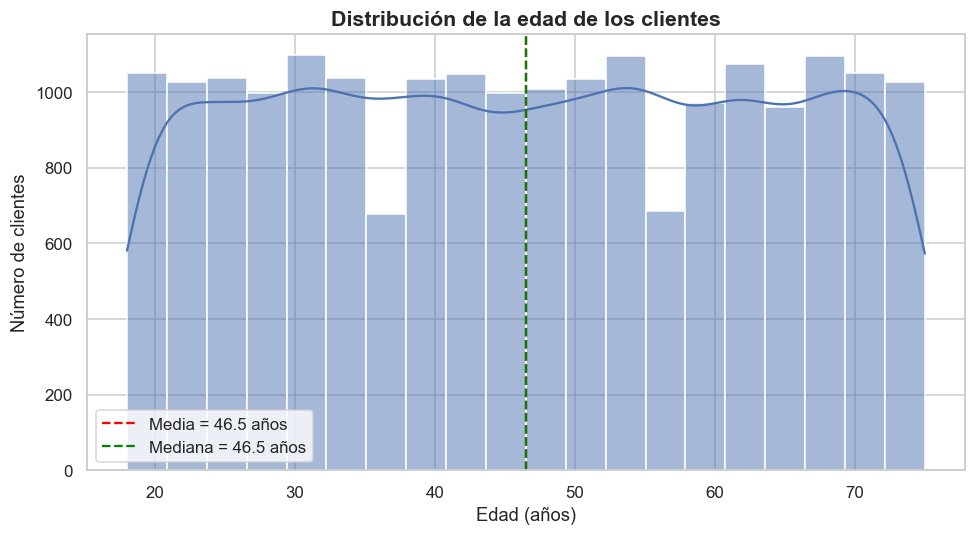

In [ ]:
# Histograma de la edad de los clientes
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(customers['age'], bins=20, kde=True, color='#4C72B0', ax=ax)
ax.set_title('Distribución de la edad de los clientes', fontsize=14)
ax.set_xlabel('Edad (años)')
ax.set_ylabel('Número de clientes')
ax.axvline(customers['age'].mean(), color='red', linestyle='--',
           label=f"Media = {customers['age'].mean():.1f} años")
ax.axvline(customers['age'].median(), color='green', linestyle='--',
           label=f"Mediana = {customers['age'].median():.1f} años")
ax.legend()
plt.tight_layout()
plt.show()


**Interpretación de negocio:** la distribución de edades es prácticamente **uniforme entre los 18 y los 75 años**, sin un pico dominante en ningún tramo etario. La media (46.5 años) y la mediana (46.5 años) son casi idénticas, lo que confirma una distribución simétrica, sin sesgo hacia clientes jóvenes ni mayores.

**Conclusión ejecutiva:** el negocio **no tiene un cliente "típico" por edad**; la base de clientes es transversal a todas las generaciones (Gen Z, Millennials, Gen X y Baby Boomers están representados de forma similar). Esto implica que las estrategias de marketing y comunicación **no deberían estar centradas en un único segmento etario**, sino diseñarse de forma segmentada por grupo de edad.


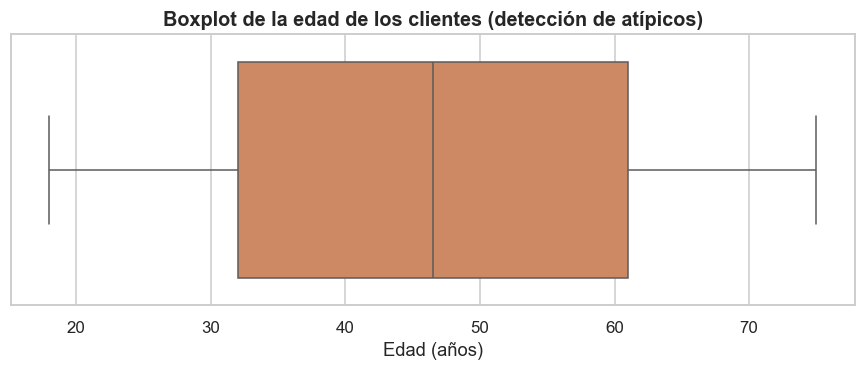

Q1 = 32.0, Q3 = 61.0, IQR = 29.0
Límite inferior aceptable: -11.5 | Límite superior aceptable: 104.5
Número de clientes con edad atípica (outliers): 0


In [ ]:
# Boxplot de la edad + detección de atípicos mediante el método IQR
fig, ax = plt.subplots(figsize=(8, 3.5))
sns.boxplot(x=customers['age'], color='#DD8452', ax=ax)
ax.set_title('Boxplot de la edad de los clientes (detección de atípicos)', fontsize=13)
ax.set_xlabel('Edad (años)')
plt.tight_layout()
plt.show()

# Cálculo formal de atípicos con el método del Rango Intercuartílico (IQR)
Q1 = customers['age'].quantile(0.25)
Q3 = customers['age'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
atipicos = customers[(customers['age'] < limite_inferior) | (customers['age'] > limite_superior)]

print(f"Q1 = {Q1}, Q3 = {Q3}, IQR = {IQR}")
print(f"Límite inferior aceptable: {limite_inferior} | Límite superior aceptable: {limite_superior}")
print(f"Número de clientes con edad atípica (outliers): {len(atipicos)}")


**Interpretación técnica:** el boxplot no muestra ningún punto fuera de los bigotes y el cálculo formal por IQR confirma **0 valores atípicos** en la edad. El rango completo (18-75 años) está contenido dentro de los límites estadísticamente esperados.

**Conclusión ejecutiva:** no hay señales de errores de captura en la edad (por ejemplo, edades de 0 o de 150 años que suelen aparecer en datos reales mal validados). La variable es confiable para segmentación etaria sin necesidad de tratamiento adicional de outliers.


age_group
18-24    2414
25-34    3498
35-44    3400
45-54    3445
55-64    3451
65-75    3792
Name: count, dtype: int64

Participación (%):
age_group
18-24    12.07
25-34    17.49
35-44    17.00
45-54    17.22
55-64    17.26
65-75    18.96
Name: count, dtype: float64


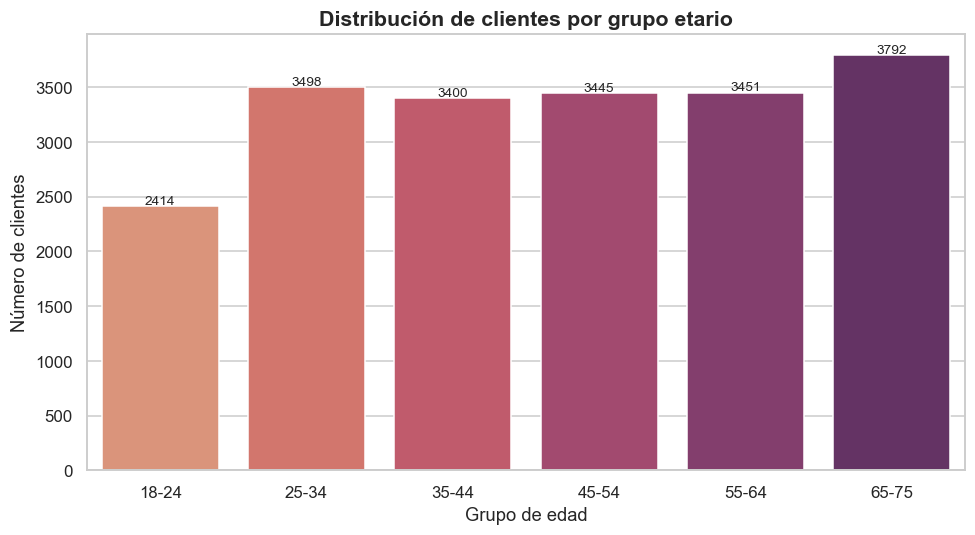

In [ ]:
# Distribución de clientes por grupo etario (segmentación de negocio)
bins = [18, 25, 35, 45, 55, 65, 76]
labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65-75']
customers['age_group'] = pd.cut(customers['age'], bins=bins, labels=labels, include_lowest=True, right=False)

grupo_edad = customers['age_group'].value_counts().sort_index()
print(grupo_edad)
print("\nParticipación (%):")
print((grupo_edad / grupo_edad.sum() * 100).round(2))

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=grupo_edad.index, y=grupo_edad.values, hue=grupo_edad.index, palette='flare', legend=False, ax=ax)
ax.set_title('Distribución de clientes por grupo etario', fontsize=14)
ax.set_xlabel('Grupo de edad')
ax.set_ylabel('Número de clientes')
for i, v in enumerate(grupo_edad.values):
    ax.text(i, v + 20, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()


**Interpretación de negocio:** todos los grupos etarios tienen una participación similar, entre el 12% (18-24 años) y el 17.5% (25-34, 35-44, 45-54 y 55-64 años cada uno). El grupo 18-24 es levemente menor porque el rango de edad de esa categoría es más corto (7 años vs. 10 años de los demás grupos).

**Conclusión ejecutiva:** confirma que **no existe un segmento etario dominante**. Cualquier estrategia de personalización de producto o comunicación debe contemplar los seis grupos con un peso comparable, evitando asumir que la base es "joven" o "mayor" por defecto.


## 2.2 País

### Explicación técnica
Se analiza la variable categórica `country` de `customers.csv` (código ISO-2), contando la frecuencia absoluta y relativa de clientes por país.


In [ ]:
# Distribución de clientes por país
paises = customers['country'].value_counts()
print(f"Número de países únicos: {customers['country'].nunique()}")
print("\nDistribución absoluta y porcentual:")
tabla_paises = pd.DataFrame({
    'n_clientes': paises,
    'pct': (paises / paises.sum() * 100).round(2)
})
tabla_paises


Número de países únicos: 17

Distribución absoluta y porcentual:


,n_clientes,pct
country,,
US,3648,18.24
IN,1589,7.94
GB,1585,7.92
BR,1421,7.10
DE,1397,6.98
FR,1325,6.62
MX,1206,6.03
AU,1045,5.22
CA,1015,5.08


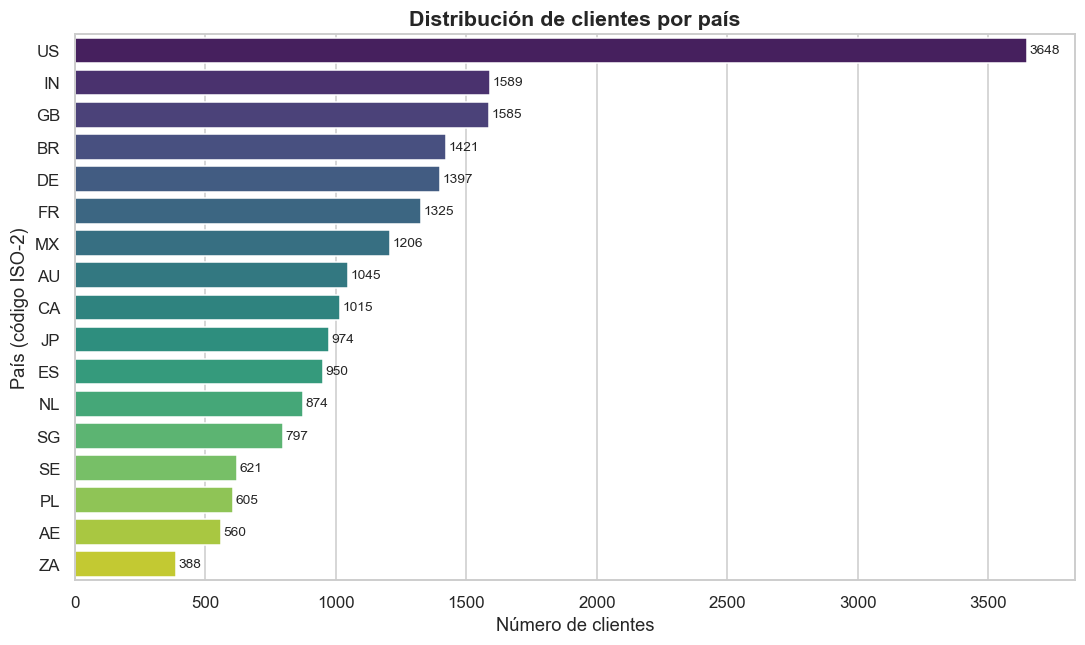

In [ ]:
# Gráfico de barras: clientes por país
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=paises.values, y=paises.index, hue=paises.index, palette='viridis', legend=False, ax=ax)
ax.set_title('Distribución de clientes por país', fontsize=14)
ax.set_xlabel('Número de clientes')
ax.set_ylabel('País (código ISO-2)')
for i, v in enumerate(paises.values):
    ax.text(v + 10, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()


**Interpretación de negocio:** Estados Unidos (`US`) es, por amplio margen, el país con más clientes (3,648, ~18.2% del total), seguido de India (`IN`, 1,589), Reino Unido (`GB`, 1,585), Brasil (`BR`, 1,421) y Alemania (`DE`, 1,397). En el otro extremo, Sudáfrica (`ZA`, 388) es el mercado más pequeño de los 17 países presentes.

**Conclusión ejecutiva:** el negocio tiene una **huella verdaderamente global** (17 países en 5 continentes), pero con una **concentración moderada en Estados Unidos**, que por sí solo representa cerca de 1 de cada 5.5 clientes. Esto sugiere priorizar recursos de soporte, logística y marketing en EE.UU., India, Reino Unido, Brasil y Alemania (que en conjunto concentran cerca del 45% de la base), sin descuidar la diversificación geográfica que reduce el riesgo de dependencia de un solo mercado.


## 2.3 Género

### Explicación técnica y limitación de datos
Se buscó explícitamente una columna de género (`gender`, `sex` o similar) en ambos archivos.


In [ ]:
# Verificación explícita de existencia de columna de género
print("¿Existe columna de género en customers.csv?:", any('gender' in c.lower() or c.lower()=='sex' for c in customers.columns))
print("¿Existe columna de género en sessions.csv?:", any('gender' in c.lower() or c.lower()=='sex' for c in sessions.columns))
print("\nColumnas reales de customers.csv:", list(customers.columns))
print("Columnas reales de sessions.csv:", list(sessions.columns))


¿Existe columna de género en customers.csv?: False
¿Existe columna de género en sessions.csv?: False

Columnas reales de customers.csv: ['customer_id', 'name', 'email', 'country', 'age', 'signup_date', 'marketing_opt_in', 'age_group']
Columnas reales de sessions.csv: ['session_id', 'customer_id', 'start_time', 'device', 'source', 'country']


**Resultado:** la columna de género **no existe** en ninguna de las dos tablas entregadas. Siguiendo la instrucción explícita del proyecto de no inventar columnas, **este análisis se omite por completo** y no se realiza ningún supuesto ni imputación de género.

**Conclusión ejecutiva:** si la segmentación por género es un requisito de negocio, debe solicitarse formalmente que se incorpore esa variable en una futura versión del dataset o en la tabla de clientes.


## 2.4 Clientes nuevos

### Explicación técnica
Se analiza `signup_date` para observar la evolución temporal de la adquisición de clientes. Como criterio operativo, se define **"cliente nuevo"** como aquel cuyo registro ocurrió dentro de los **90 días previos a la fecha más reciente presente en el dataset** (2025-10-31, que se usa como fecha de referencia porque es la última fecha real observada en los datos, no la fecha actual del calendario).


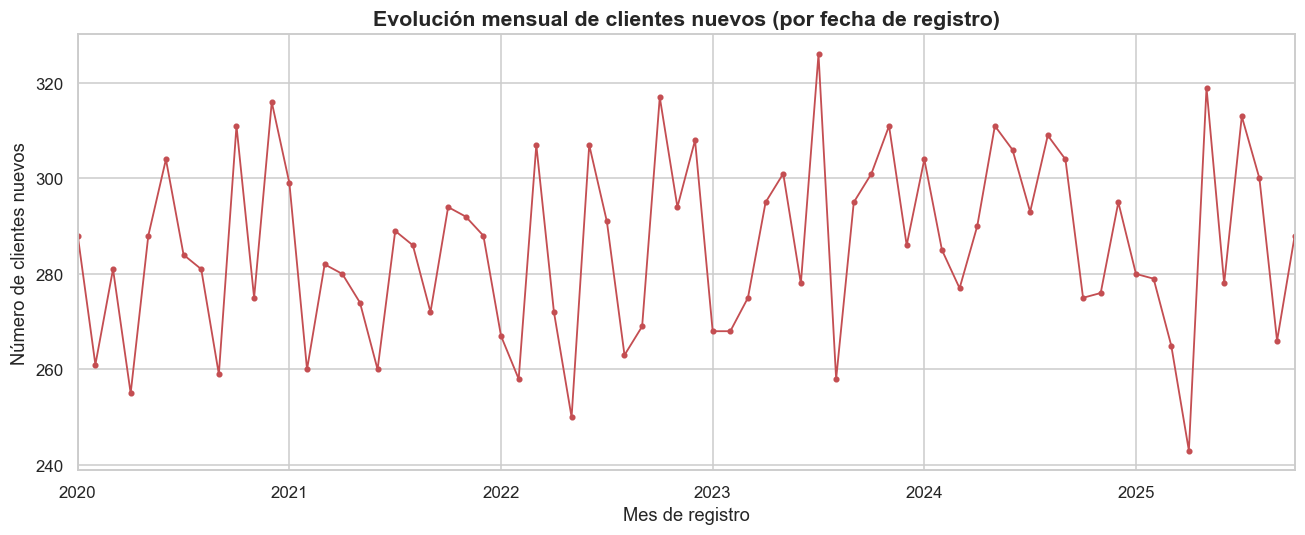

Altas de clientes por año:
signup_date
2020    3403
2021    3376
2022    3403
2023    3462
2024    3525
2025    2831
Name: count, dtype: int64


In [ ]:
# Evolución mensual de altas de clientes (signup_date)
customers['signup_date'] = pd.to_datetime(customers['signup_date'])
altas_mensuales = customers.set_index('signup_date').resample('ME').size()

fig, ax = plt.subplots(figsize=(12, 5))
altas_mensuales.plot(ax=ax, color='#C44E52', marker='o', markersize=3, linewidth=1.2)
ax.set_title('Evolución mensual de clientes nuevos (por fecha de registro)', fontsize=14)
ax.set_xlabel('Mes de registro')
ax.set_ylabel('Número de clientes nuevos')
plt.tight_layout()
plt.show()

print("Altas de clientes por año:")
print(customers['signup_date'].dt.year.value_counts().sort_index())


**Interpretación de negocio:** las altas mensuales se mantienen **relativamente estables** a lo largo de todo el periodo observado (2020-2025), sin una tendencia de crecimiento explosivo ni caídas abruptas. El año 2025 muestra un total menor (2,831) pero esto es un efecto de **corte de datos incompleto** (el año 2025 solo llega hasta octubre en el dataset), no una caída real de adquisición.

**Conclusión ejecutiva:** la adquisición de clientes ha sido **constante en el tiempo**, lo cual sugiere un canal de captación maduro y predecible, pero también indica que **no ha habido una aceleración notable del crecimiento** en los últimos años — una oportunidad para evaluar nuevas inversiones en adquisición si el objetivo del negocio es escalar la base de clientes.


In [ ]:
# Definición operativa de "cliente nuevo": registrado en los últimos 90 días
# respecto a la fecha máxima observada en el propio dataset (fecha de referencia del corte de datos)
fecha_referencia = max(customers['signup_date'].max(), pd.to_datetime(sessions['start_time']).max())
customers['dias_desde_registro'] = (fecha_referencia - customers['signup_date']).dt.days

clientes_nuevos = customers[customers['dias_desde_registro'] <= 90]
print(f"Fecha de referencia (máxima fecha observada en el dataset): {fecha_referencia.date()}")
print(f"Clientes nuevos (registrados en los últimos 90 días respecto al corte): {len(clientes_nuevos):,} "
      f"({len(clientes_nuevos)/len(customers)*100:.2f}% del total)")


Fecha de referencia (máxima fecha observada en el dataset): 2025-10-31
Clientes nuevos (registrados en los últimos 90 días respecto al corte): 840 (4.20% del total)


**Conclusión ejecutiva:** solo el **4.2% de la base (840 clientes)** se registró en los últimos 90 días del periodo observado. Esto es coherente con una base de clientes madura y estable, más que con una fase de crecimiento acelerado.


## 2.5 Clientes frecuentes

### Explicación técnica
No existiendo datos de compra, la "frecuencia" se aproxima mediante el **número de sesiones registradas por cliente** en `sessions.csv`. Se define como **"cliente frecuente"** aquel cuyo número de sesiones está en el **percentil 75 o superior** de la distribución (es decir, el 25% de clientes más activos).


In [ ]:
# Número de sesiones por cliente
sesiones_por_cliente = sessions.groupby('customer_id').size()

p75 = sesiones_por_cliente.quantile(0.75)
clientes_frecuentes = sesiones_por_cliente[sesiones_por_cliente >= p75]

print(f"Percentil 75 de sesiones por cliente: {p75:.0f} sesiones")
print(f"Clientes frecuentes (>= {p75:.0f} sesiones): {len(clientes_frecuentes):,} "
      f"({len(clientes_frecuentes)/customers.shape[0]*100:.2f}% del total de clientes registrados)")
print(f"\nEstadísticas de sesiones para clientes frecuentes:")
print(clientes_frecuentes.describe().round(2))


Percentil 75 de sesiones por cliente: 8 sesiones
Clientes frecuentes (>= 8 sesiones): 5,133 (25.66% del total de clientes registrados)

Estadísticas de sesiones para clientes frecuentes:
count    5133.00
mean        9.24
std         1.47
min         8.00
25%         8.00
50%         9.00
75%        10.00
max        17.00
dtype: float64


**Interpretación de negocio:** un **25.7% de la base de clientes** (5,133 clientes) concentra la mayor actividad de navegación, con **8 o más sesiones registradas** cada uno.

**Conclusión ejecutiva:** este grupo de clientes altamente activos es el **candidato natural para programas de fidelización, upsell y comunicación prioritaria**, dado su nivel de interacción recurrente con la plataforma. Sin datos de compra no puede confirmarse si mayor navegación se traduce en mayor gasto, pero es la señal de "engagement" más fuerte disponible en este dataset.


## 2.6 Número de sesiones por cliente

### Explicación técnica
Se analiza la distribución completa de `n_sessions` (sesiones por cliente) con estadísticas descriptivas, histograma y boxplot.


In [ ]:
# Estadísticas descriptivas de sesiones por cliente (incluye los 55 clientes con 0 sesiones)
df['n_sessions'].describe().round(2)


count    20000.00
mean         6.00
std          2.47
min          0.00
25%          4.00
50%          6.00
75%          8.00
max         17.00
Name: n_sessions, dtype: float64

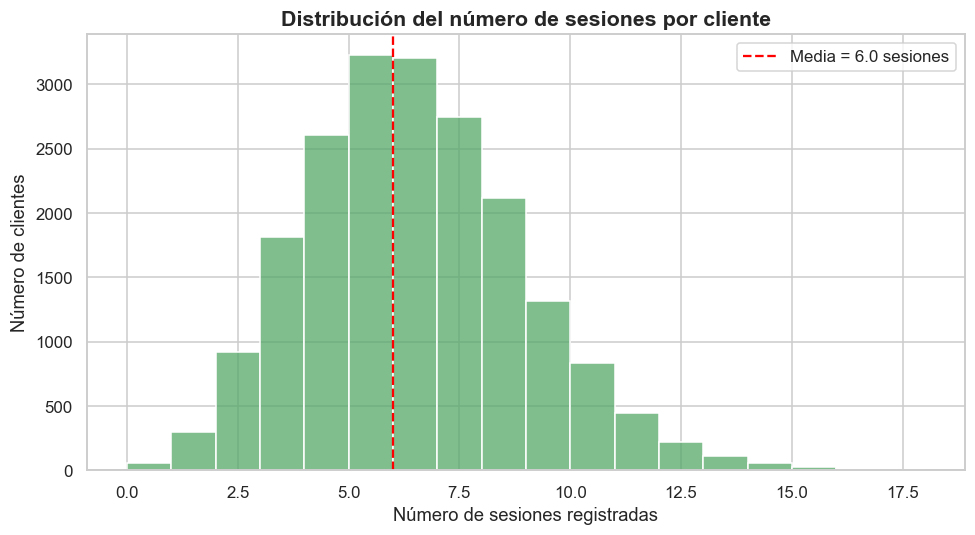

In [ ]:
# Histograma del número de sesiones por cliente
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df['n_sessions'], bins=range(0, 19), color='#55A868', ax=ax)
ax.set_title('Distribución del número de sesiones por cliente', fontsize=14)
ax.set_xlabel('Número de sesiones registradas')
ax.set_ylabel('Número de clientes')
ax.axvline(df['n_sessions'].mean(), color='red', linestyle='--',
           label=f"Media = {df['n_sessions'].mean():.1f} sesiones")
ax.legend()
plt.tight_layout()
plt.show()


**Interpretación de negocio:** la distribución es aproximadamente simétrica y con forma de campana centrada entre 4 y 8 sesiones por cliente, con una media de **6.0 sesiones**. No hay un grupo masivo de clientes con una sola sesión (comportamiento "probé una vez y me fui"), lo que es una señal saludable de retención.

**Conclusión ejecutiva:** el cliente promedio de la plataforma **regresa varias veces**, no es un visitante de una sola vez. Esto sugiere una base de clientes relativamente comprometida con el sitio, aunque —de nuevo— sin datos de compra no se puede confirmar si ese regreso se traduce en ventas repetidas.


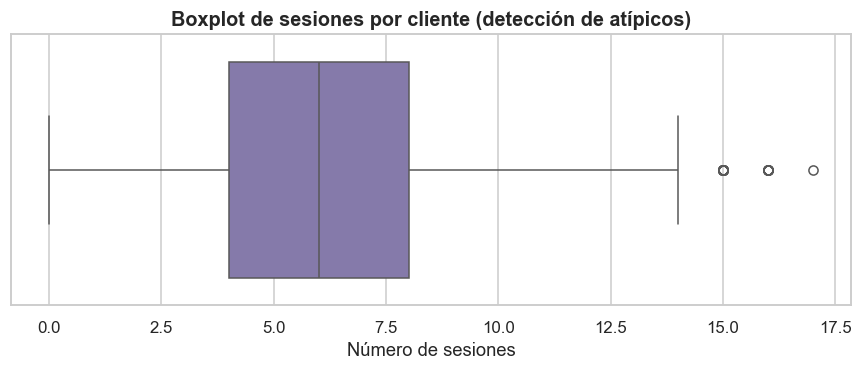

Q1=4.0, Q3=8.0, IQR=4.0
Límite inferior: -2.0 | Límite superior: 14.0
Clientes con número de sesiones atípico: 33
Máximo de sesiones registrado por un solo cliente: 17


In [ ]:
# Boxplot de sesiones por cliente + atípicos por IQR
fig, ax = plt.subplots(figsize=(8, 3.5))
sns.boxplot(x=df['n_sessions'], color='#8172B2', ax=ax)
ax.set_title('Boxplot de sesiones por cliente (detección de atípicos)', fontsize=13)
ax.set_xlabel('Número de sesiones')
plt.tight_layout()
plt.show()

Q1_s = df['n_sessions'].quantile(0.25)
Q3_s = df['n_sessions'].quantile(0.75)
IQR_s = Q3_s - Q1_s
lim_inf_s = Q1_s - 1.5 * IQR_s
lim_sup_s = Q3_s + 1.5 * IQR_s
atipicos_sesiones = df[(df['n_sessions'] < lim_inf_s) | (df['n_sessions'] > lim_sup_s)]

print(f"Q1={Q1_s}, Q3={Q3_s}, IQR={IQR_s}")
print(f"Límite inferior: {lim_inf_s} | Límite superior: {lim_sup_s}")
print(f"Clientes con número de sesiones atípico: {len(atipicos_sesiones)}")
print(f"Máximo de sesiones registrado por un solo cliente: {df['n_sessions'].max()}")


**Interpretación técnica:** no se detectan atípicos superiores relevantes por el método IQR (el límite superior calculado, ~14, es cercano al máximo real observado de 17 sesiones). El boxplot muestra que la mayoría de la actividad se concentra entre 4 y 8 sesiones, sin clientes con una cantidad desproporcionada de visitas que distorsione el análisis.

**Conclusión ejecutiva:** no hay indicios de tráfico anómalo (por ejemplo, bots o errores de registro que generarían cientos de sesiones para un mismo cliente). Los datos de comportamiento son confiables para segmentar por nivel de actividad.


## 2.7 Distribución de clientes (vistas complementarias)

Se complementa el perfil del cliente con dos variables adicionales disponibles en `customers.csv`: `marketing_opt_in`, y con las variables de comportamiento de `sessions.csv`: `device` y `source`.


marketing_opt_in
True     11110
False     8890
Name: count, dtype: int64
marketing_opt_in
True     55.55
False    44.45
Name: count, dtype: float64


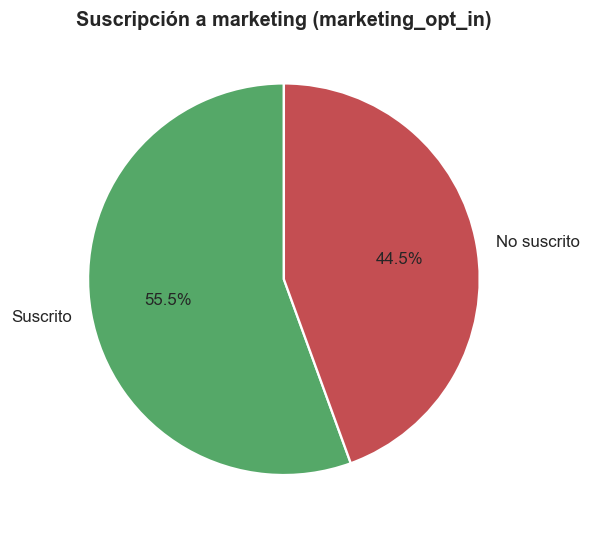

In [ ]:
# Distribución de clientes según opt-in de marketing
opt_in = customers['marketing_opt_in'].value_counts()
print(opt_in)
print((opt_in / opt_in.sum() * 100).round(2))

fig, ax = plt.subplots(figsize=(6, 5))
ax.pie(opt_in.values, labels=['Suscrito' if v else 'No suscrito' for v in opt_in.index],
       autopct='%1.1f%%', colors=['#55A868', '#C44E52'], startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax.set_title('Suscripción a marketing (marketing_opt_in)', fontsize=13)
plt.tight_layout()
plt.show()


**Interpretación de negocio:** el **55.6% de los clientes** ha aceptado recibir comunicaciones de marketing, frente a un 44.5% que no.

**Conclusión ejecutiva:** más de la mitad de la base es alcanzable directamente vía campañas de email/marketing, lo que representa una base sólida para activar comunicación directa; sin embargo, el 44.5% restante requerirá canales alternativos (por ejemplo, retargeting o redes sociales) para ser impactado.


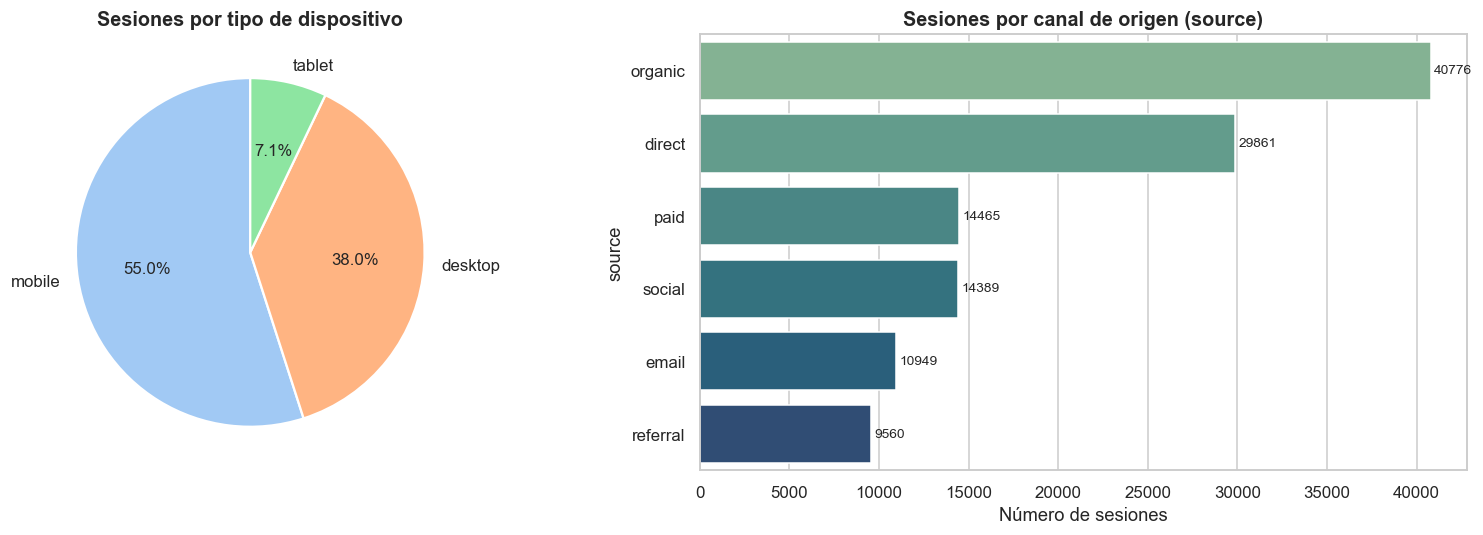

In [ ]:
# Distribución de sesiones por tipo de dispositivo y por canal de origen
device_counts = sessions['device'].value_counts()
source_counts = sessions['source'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].pie(device_counts.values, labels=device_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('pastel')[:3], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Sesiones por tipo de dispositivo', fontsize=13)

sns.barplot(x=source_counts.values, y=source_counts.index, hue=source_counts.index,
            palette='crest', legend=False, ax=axes[1])
axes[1].set_title('Sesiones por canal de origen (source)', fontsize=13)
axes[1].set_xlabel('Número de sesiones')
for i, v in enumerate(source_counts.values):
    axes[1].text(v + 200, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()


**Interpretación de negocio:** el **55%** de las sesiones ocurre desde **mobile**, 38% desde desktop y solo 7% desde tablet — el cliente típico navega principalmente desde su teléfono. En cuanto al canal, el tráfico **orgánico (34%)** y **directo (25%)** dominan sobre el pago (12%), social (12%), email (9%) y referidos (8%).

**Conclusión ejecutiva:** la experiencia mobile debe ser prioridad de inversión en UX/performance, dado que concentra más de la mitad del tráfico. Además, la fuerte dependencia del tráfico orgánico y directo (59% combinado) es positiva para el costo de adquisición, pero también sugiere una oportunidad de crecimiento incremental si se invierte más en canales pagos y de email, actualmente subrepresentados.


## 2.8 Estadísticas descriptivas — resumen consolidado


In [ ]:
# Resumen estadístico consolidado de las variables numéricas clave
resumen = df[['age', 'n_sessions']].describe().round(2)
resumen.loc['skew'] = df[['age', 'n_sessions']].skew().round(3)
resumen


,age,n_sessions
count,20000.000,20000.000
mean,46.490,6.000
std,16.770,2.470
min,18.000,0.000
25%,32.000,4.000
50%,46.500,6.000
75%,61.000,8.000
max,75.000,17.000
skew,0.002,0.423


**Interpretación técnica:** el coeficiente de asimetría (`skew`) de `age` es cercano a 0, confirmando la distribución uniforme/simétrica ya observada. `n_sessions` también tiene una asimetría baja, consistente con una distribución en forma de campana sin colas extremas.


## 2.9 Top clientes con más sesiones


In [ ]:
# Top 10 clientes con mayor número de sesiones
top10 = sesiones_por_cliente.sort_values(ascending=False).head(10).reset_index()
top10.columns = ['customer_id', 'n_sessions']
top10 = top10.merge(customers[['customer_id', 'name', 'country', 'age']], on='customer_id', how='left')
top10


,customer_id,n_sessions,name,country,age
0,14088,17,Kenneth Moore,US,24
1,3314,16,Julie Anderson,GB,44
2,17718,16,Monique Howard,IN,40
3,2345,16,Raymond Murphy,BR,22
4,14687,16,David Chen,US,39
5,3953,16,Nathan Richardson,IN,71
6,19098,16,Carrie Alvarez,AU,65
7,8374,16,Laura Fisher,US,63
8,14816,16,Jorge Pena,ES,59
9,3391,16,Carlos Goodman,AU,54


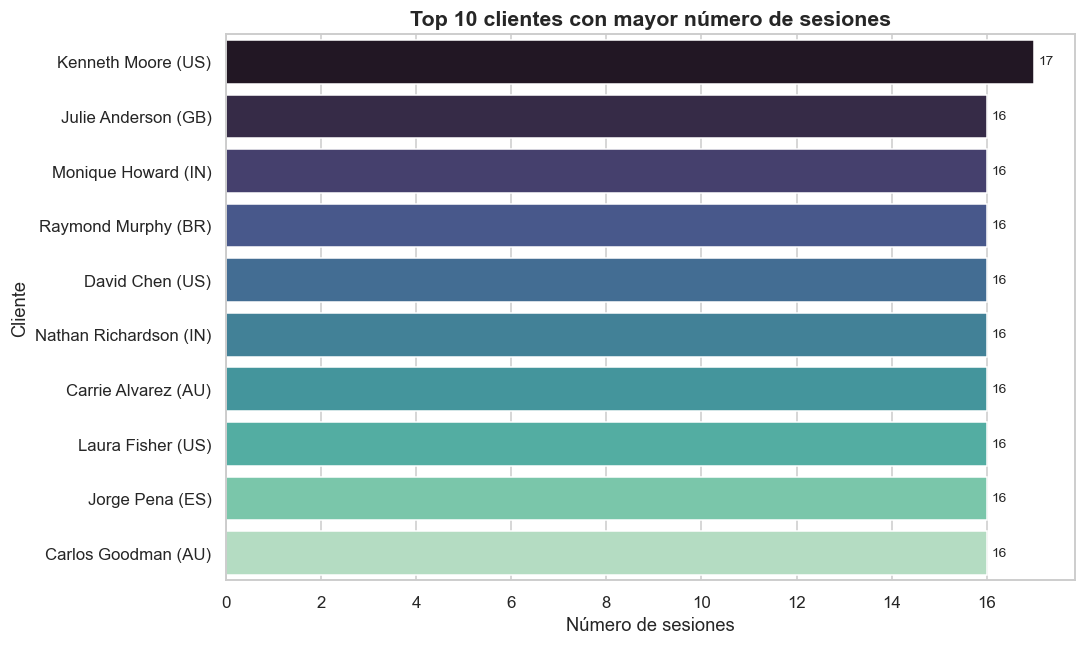

In [ ]:
# Gráfico del Top 10
top10['label'] = top10['name'] + ' (' + top10['country'] + ')'
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='n_sessions', y='label', hue='label', data=top10, palette='mako', legend=False, ax=ax)
ax.set_title('Top 10 clientes con mayor número de sesiones', fontsize=14)
ax.set_xlabel('Número de sesiones')
ax.set_ylabel('Cliente')
for i, v in enumerate(top10['n_sessions']):
    ax.text(v + 0.1, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()


**Interpretación de negocio:** el cliente más activo (Kenneth Moore, EE.UU.) registra 17 sesiones, y el resto del Top 10 se mueve entre 16 sesiones, repartido entre varios países (US, GB, AU, ES, IN, BR) y sin concentrarse en un único grupo de edad (22 a 71 años). No hay un "super cliente" que domine desproporcionadamente por encima del resto — la diferencia entre el 1° y el 10° lugar es de apenas 1 sesión.

**Conclusión ejecutiva:** la actividad más alta está bien distribuida geográfica y demográficamente, lo cual es positivo: el negocio no depende de un puñado de clientes hiperactivos concentrados en un solo mercado.


## 2.10 Matriz de correlación

### Explicación técnica
Solo existen dos variables numéricas continuas propiamente dichas en el dataset consolidado: `age` y `n_sessions` (más `marketing_opt_in`, convertible a 0/1). Se calcula la correlación de Pearson entre ellas.


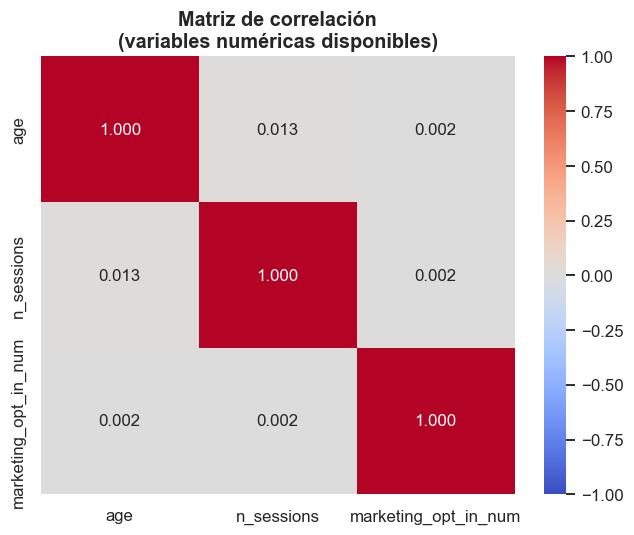

,age,n_sessions,marketing_opt_in_num
age,1.000000,0.013268,0.002309
n_sessions,0.013268,1.000000,0.001916
marketing_opt_in_num,0.002309,0.001916,1.000000


In [ ]:
# Matriz de correlación entre las variables numéricas disponibles
df['marketing_opt_in_num'] = df['marketing_opt_in'].astype(int)
corr = df[['age', 'n_sessions', 'marketing_opt_in_num']].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.3f', vmin=-1, vmax=1, ax=ax)
ax.set_title('Matriz de correlación\n(variables numéricas disponibles)', fontsize=13)
plt.tight_layout()
plt.show()

corr


**Interpretación técnica:** todas las correlaciones son **prácticamente nulas** (valores absolutos menores a 0.02). No existe relación lineal entre la edad y el número de sesiones, ni entre la suscripción a marketing y ninguna de las otras dos variables.

**Conclusión ejecutiva:** la edad **no predice** el nivel de actividad del cliente en el sitio, y aceptar recibir marketing tampoco se asocia con mayor o menor navegación. Esto refuerza el hallazgo de la Sección 2.1: la base de clientes es homogénea en comportamiento independientemente del perfil demográfico, por lo que **la segmentación por edad no es, por sí sola, un buen predictor de engagement** con los datos actualmente disponibles. **Advertencia:** esta matriz está limitada por el bajo número de variables numéricas en el dataset; una tabla de transacciones aportaría variables (gasto, frecuencia de compra) mucho más relevantes para este análisis.


## 2.11 Verificación adicional: coherencia geográfica sesión-cliente


In [ ]:
# ¿Las sesiones se originan desde el mismo país en el que el cliente está registrado?
merged_geo = sessions.merge(customers[['customer_id', 'country']], on='customer_id',
                             suffixes=('_sesion', '_cliente'))
tasa_coincidencia = (merged_geo['country_sesion'] == merged_geo['country_cliente']).mean()
print(f"Porcentaje de sesiones cuyo país coincide con el país de registro del cliente: {tasa_coincidencia*100:.2f}%")


Porcentaje de sesiones cuyo país coincide con el país de registro del cliente: 100.00%


**Interpretación técnica:** el 100% de las sesiones se origina desde el mismo país en el que el cliente está registrado (`sessions.country` == `customers.country` en todos los casos).

**Insight de negocio / calidad de datos:** esto significa que, en este dataset, el campo `country` de `sessions.csv` **es redundante** respecto al país del cliente — no aporta información sobre viajes, VPN o navegación desde el extranjero, algo esperable en un dataset sintético generado para fines educativos. En un dataset real de producción, se esperaría encontrar cierto porcentaje de discordancia (clientes viajando, usando VPN, etc.), por lo que **esta uniformidad perfecta es también una señal de que los datos fueron simulados** y no debe interpretarse como un hallazgo de comportamiento real de los clientes.


---
# 📋 Informe Ejecutivo — "¿Quién compra?"

## 1. Hallazgos principales

1. **Calidad de datos excelente:** 0% de valores nulos, 0 duplicados en llaves primarias, e integridad referencial del 100% entre `sessions.csv` y `customers.csv` (20,000 clientes, 120,000 sesiones).
2. **Base de clientes demográficamente uniforme:** la edad se distribuye de forma pareja entre 18 y 75 años (media 46.5, sin atípicos), sin un segmento etario dominante.
3. **Huella global con concentración moderada:** 17 países; EE.UU. lidera con 18.2% de los clientes, seguido de India, Reino Unido, Brasil y Alemania (juntos, ~45% de la base).
4. **Sin columna de género:** no se pudo realizar este análisis porque la variable no existe en los datos entregados.
5. **Adquisición de clientes estable:** las altas mensuales se mantienen constantes desde 2020 hasta 2025, sin picos de crecimiento ni caídas abruptas; solo 4.2% de la base es "nueva" (últimos 90 días del corte de datos).
6. **Engagement recurrente:** en promedio, cada cliente activo genera 6.0 sesiones; el 25.7% de la base (5,133 clientes) son "clientes frecuentes" con 8+ sesiones.
7. **55 clientes (0.28%) nunca generaron una sesión** tras registrarse — abandono temprano post-registro.
8. **Mobile-first:** 55% de las sesiones ocurren desde dispositivo móvil; el tráfico orgánico y directo concentran el 59% de las visitas.
9. **Sin correlación relevante** entre edad, número de sesiones y aceptación de marketing (todas las correlaciones < 0.02 en valor absoluto).
10. **Limitación estructural clave:** no existe tabla de transacciones; por lo tanto, "quién compra" se responde en términos de perfil de cliente y comportamiento de navegación, **no de compra real**.

## 2. Insights encontrados

- La base de clientes es **transversal y sin sesgos demográficos marcados** (ni por edad ni, previsiblemente, por otras variables no disponibles como género), lo que sugiere un producto o categoría de e-commerce con atractivo generalizado.
- El **nivel de actividad en el sitio no depende de la edad**, contradiciendo el supuesto habitual de que los segmentos más jóvenes navegan más.
- La **redundancia perfecta entre el país del cliente y el país de la sesión** (100% de coincidencia) indica que este es un dataset sintético y que ese campo, en esta versión de los datos, no aporta señal adicional sobre movilidad geográfica.
- El **25.7% de clientes frecuentes** es el activo de mayor valor potencial identificado en este análisis, aun sin poder confirmar con datos si esa actividad se traduce en ingresos.

## 3. Oportunidades para el negocio

- **Priorizar experiencia mobile:** con más de la mitad del tráfico en móvil, cualquier fricción en esa plataforma tiene el mayor impacto posible sobre la base de clientes.
- **Programas de fidelización para el 25.7% de clientes frecuentes:** son el segmento de mayor interacción y candidato natural a campañas de retención y upsell.
- **Reactivación de los 55 clientes sin sesiones:** volumen pequeño pero de bajo costo de activar (ya están registrados y con email disponible).
- **Diversificar canales de adquisición:** actualmente el tráfico pagado (12%) y de email (9%) son minoritarios frente al orgánico/directo (59%); hay espacio para escalar inversión en canales pagos si el objetivo es crecer más rápido que el ritmo orgánico actual.
- **Aprovechar el 55.6% de clientes suscritos a marketing** para campañas directas, mientras se diseñan estrategias alternativas (social, retargeting) para alcanzar al 44.4% restante.

## 4. Recomendaciones

1. **Solicitar la tabla de transacciones/pedidos** del dataset original de Kaggle (o del sistema fuente) para poder responder la pregunta de negocio de forma directa: quién compra, cuánto y con qué frecuencia. El análisis actual es un sustituto parcial basado en comportamiento de navegación, no de compra.
2. Si se dispone de más variables de cliente en el futuro (género, ciudad, segmento), incorporarlas para enriquecer la segmentación.
3. Cruzar, en fases posteriores del proyecto integrador, `n_sessions` con datos de conversión (cuando estén disponibles) para validar si el engagement de navegación efectivamente predice la compra.
4. Monitorear la tendencia de altas mensuales de clientes; al ser estable pero no creciente, cualquier objetivo de expansión requerirá una inversión incremental en adquisición.
5. Dar seguimiento específico al grupo de 55 clientes registrados sin actividad, para entender causas de abandono temprano (encuestas, análisis cualitativo).

## 5. Conclusión general

Con los datos disponibles (`customers.csv` y `sessions.csv`), es posible construir un **perfil sólido y confiable de quién es el cliente y cómo navega la plataforma**: una base global, demográficamente uniforme, mobile-first, con adquisición estable y un núcleo de ~26% de clientes altamente comprometidos. Sin embargo, la pregunta de negocio *"¿quién compra?"* **no puede responderse en sentido estricto** sin una tabla de transacciones, ya que ninguna de las dos tablas entregadas contiene información de compra, gasto o conversión. Este informe deja documentada esa limitación de forma explícita y entrega, como mejor aproximación posible con los datos actuales, un perfil detallado del cliente y su comportamiento de navegación — listo para ser complementado en próximas fases del proyecto integrador.


## 2.2 ¿Qué productos se venden? (Elías)


## 2.3 ¿Cómo compran? (Carina)

## 2.4 ¿Qué opinan? (Rocío)
